##

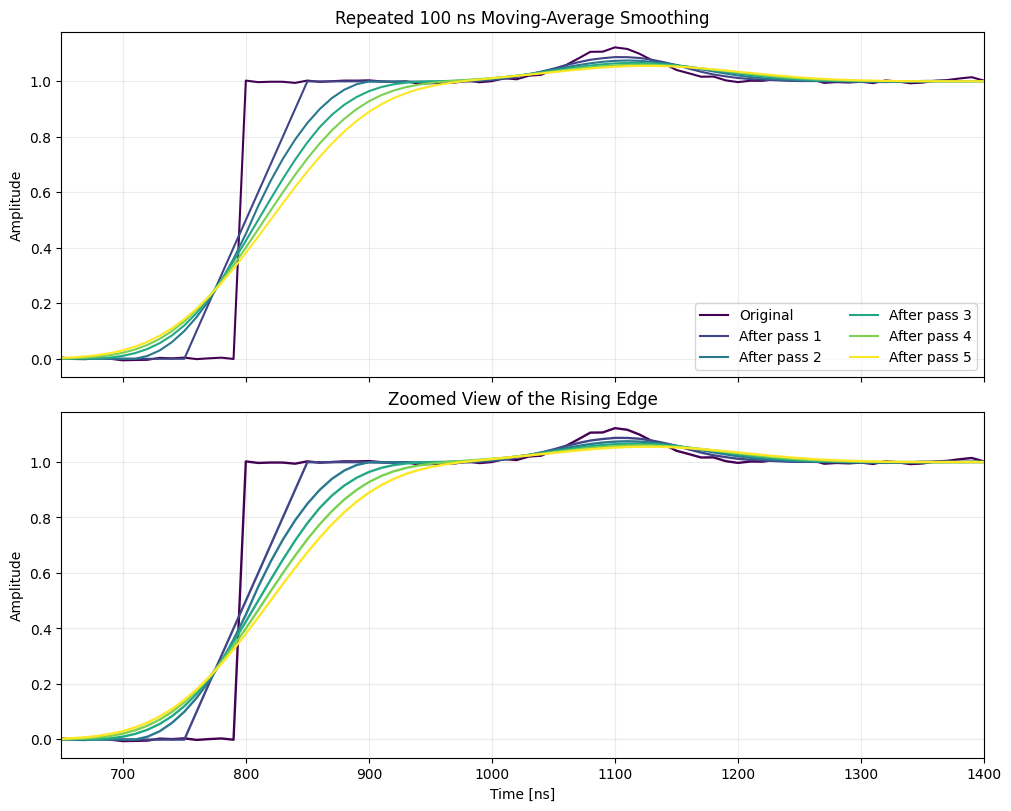

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def moving_average(signal, window_samples):
    """Centered moving average with edge padding."""
    left_pad = window_samples // 2
    right_pad = window_samples - 1 - left_pad

    padded = np.pad(signal, (left_pad, right_pad), mode="edge")
    kernel = np.ones(window_samples) / window_samples

    return np.convolve(padded, kernel, mode="valid")


def repeated_smoothing(signal, window_ns, repetitions, sampling_ns=10):
    """Apply the same moving-average filter repeatedly."""
    window_samples = round(window_ns / sampling_ns)

    filtered_stages = [signal.copy()]

    for _ in range(repetitions):
        filtered_stages.append(
            moving_average(filtered_stages[-1], window_samples)
        )

    return filtered_stages


# --------------------------------------------------
# 1. Simulate a waveform sampled every 10 ns
# --------------------------------------------------

rng = np.random.default_rng(42)

sampling_ns = 10
time_ns = np.arange(0, 3000, sampling_ns)

# Smooth rising pulse with a small localized feature
pulse = np.where(
    time_ns >= 800,
    # 1.0 - np.exp(-(time_ns - 800) / 70),
    1.0,
    0.0,
)

small_feature = 0.12 * np.exp(
    -0.5 * ((time_ns - 1100) / 35) ** 2
)

noise = rng.normal(0, 0.005, size=time_ns.size)

waveform = pulse + small_feature + noise


# --------------------------------------------------
# 2. Apply a 100 ns moving average five times
# --------------------------------------------------

stages = repeated_smoothing(
    waveform,
    window_ns=100,
    repetitions=5,
    sampling_ns=sampling_ns,
)


# --------------------------------------------------
# 3. Plot every filtering stage
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
)

colors = plt.cm.viridis(np.linspace(0, 1, len(stages)))

for i, filtered_waveform in enumerate(stages):
    label = "Original" if i == 0 else f"After pass {i}"

    axes[0].plot(
        time_ns,
        filtered_waveform,
        color=colors[i],
        linewidth=1.5,
        label=label,
    )

axes[0].set_ylabel("Amplitude")
axes[0].set_title("Repeated 100 ns Moving-Average Smoothing")
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.25)


# Zoom into the rising edge
for i, filtered_waveform in enumerate(stages):
    label = "Original" if i == 0 else f"100 ns × {i}"

    axes[1].plot(
        time_ns,
        filtered_waveform,
        color=colors[i],
        linewidth=1.7,
        label=label,
    )

axes[1].set_xlim(650, 1400)
axes[1].set_xlabel("Time [ns]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Zoomed View of the Rising Edge")
axes[1].grid(alpha=0.25)

plt.show()

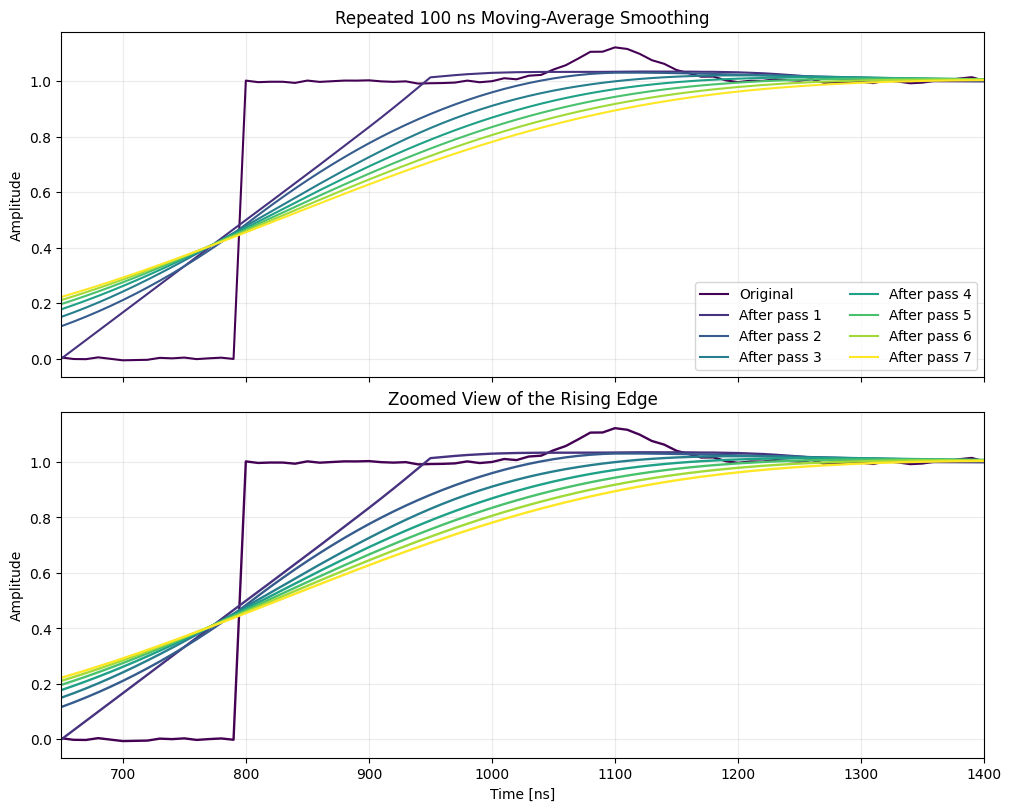

In [3]:

stages = repeated_smoothing(
    waveform,
    window_ns=300,
    repetitions=7,
    sampling_ns=sampling_ns,
)


# --------------------------------------------------
# 3. Plot every filtering stage
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
)

colors = plt.cm.viridis(np.linspace(0, 1, len(stages)))

for i, filtered_waveform in enumerate(stages):
    label = "Original" if i == 0 else f"After pass {i}"

    axes[0].plot(
        time_ns,
        filtered_waveform,
        color=colors[i],
        linewidth=1.5,
        label=label,
    )

axes[0].set_ylabel("Amplitude")
axes[0].set_title("Repeated 100 ns Moving-Average Smoothing")
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.25)


# Zoom into the rising edge
for i, filtered_waveform in enumerate(stages):
    label = "Original" if i == 0 else f"100 ns × {i}"

    axes[1].plot(
        time_ns,
        filtered_waveform,
        color=colors[i],
        linewidth=1.7,
        label=label,
    )

axes[1].set_xlim(650, 1400)
axes[1].set_xlabel("Time [ns]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Zoomed View of the Rising Edge")
axes[1].grid(alpha=0.25)

plt.show()

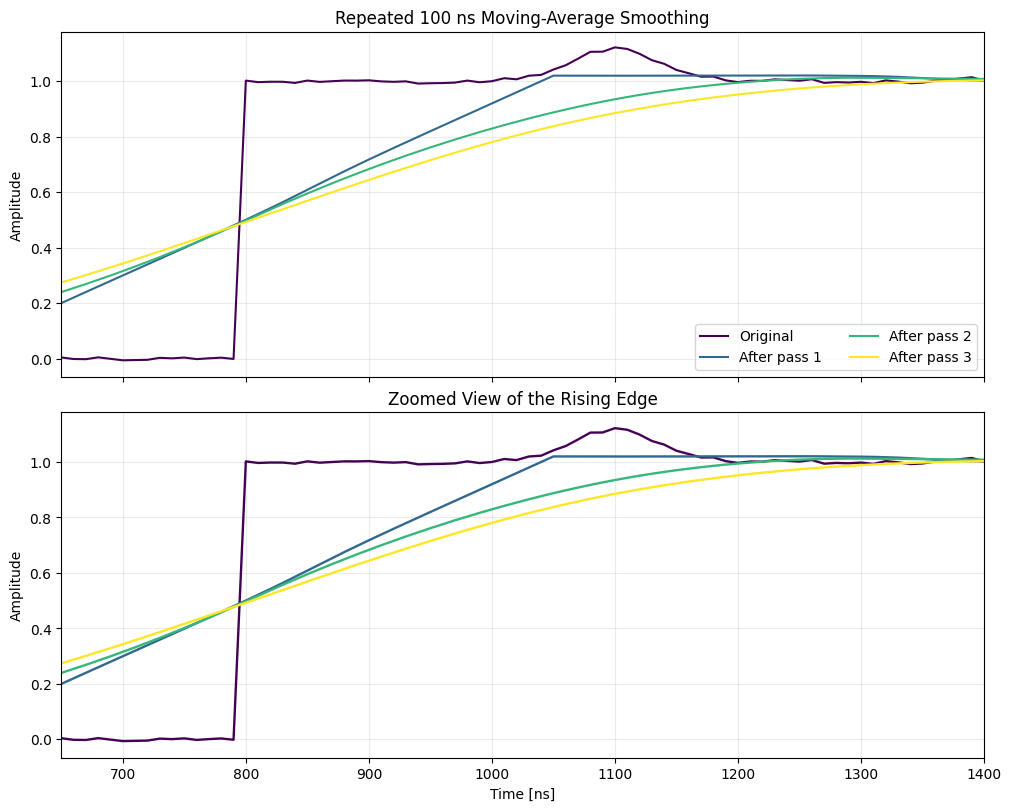

In [4]:

stages = repeated_smoothing(
    waveform,
    window_ns=500,
    repetitions=3,
    sampling_ns=sampling_ns,
)


# --------------------------------------------------
# 3. Plot every filtering stage
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    constrained_layout=True,
)

colors = plt.cm.viridis(np.linspace(0, 1, len(stages)))

for i, filtered_waveform in enumerate(stages):
    label = "Original" if i == 0 else f"After pass {i}"

    axes[0].plot(
        time_ns,
        filtered_waveform,
        color=colors[i],
        linewidth=1.5,
        label=label,
    )

axes[0].set_ylabel("Amplitude")
axes[0].set_title("Repeated 100 ns Moving-Average Smoothing")
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.25)


# Zoom into the rising edge
for i, filtered_waveform in enumerate(stages):
    label = "Original" if i == 0 else f"100 ns × {i}"

    axes[1].plot(
        time_ns,
        filtered_waveform,
        color=colors[i],
        linewidth=1.7,
        label=label,
    )

axes[1].set_xlim(650, 1400)
axes[1].set_xlabel("Time [ns]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Zoomed View of the Rising Edge")
axes[1].grid(alpha=0.25)

plt.show()

/tmp/ipykernel_417925/3223439847.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


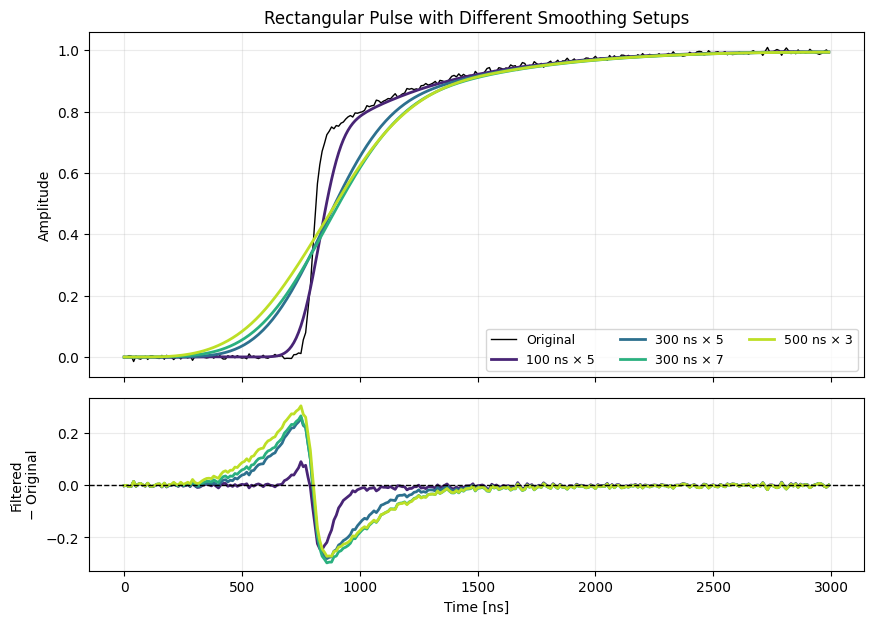

In [27]:
# Setups: (window size in ns, number of passes)
t0 = 800

tanh_width = 30       # Smoothness of the initial edge
tail_time = 500       # Duration of the long rise
initial_height = 0.7

dt = time_ns - t0

# Smooth replacement for the sharp onset
onset = 0.5 * (
    1 + np.tanh(dt / tanh_width)
)

# Long rise from 0.7 toward 1.0
long_tail = (
    1
    - (1 - initial_height)
    * np.exp(-np.maximum(dt, 0) / tail_time)
)

pulse = onset * long_tail

noise = rng.normal(0, 0.005, size=time_ns.size)

waveform = pulse  + noise

setups = [
    (100, 5),
    (300, 5),
    (300, 7),
    (500, 3),
]
fig, (ax_waveform, ax_residual) = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1],
        "hspace": 0.08,
    },
)

colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(setups))
)


# Original rectangular waveform
ax_waveform.plot(
    time_ns,
    waveform,
    color="black",
    linestyle="-",
    linewidth=1,
    label="Original",
)


# Apply and plot each smoothing setup
for color, (window_ns, repetitions) in zip(colors, setups):

    stages = repeated_smoothing(
        waveform,
        window_ns=window_ns,
        repetitions=repetitions,
        sampling_ns=sampling_ns,
    )

    # Only take the final result
    filtered = stages[-1]
    residual = filtered - waveform

    label = f"{window_ns} ns × {repetitions}"

    # Smoothed waveform
    ax_waveform.plot(
        time_ns,
        filtered,
        color=color,
        linewidth=2,
        label=label,
    )

    # Residual
    ax_residual.plot(
        time_ns,
        residual,
        color=color,
        linewidth=2,
        label=label,
    )


# Top panel
ax_waveform.set_ylabel("Amplitude")
ax_waveform.set_title(
    "Rectangular Pulse with Different Smoothing Setups"
)
ax_waveform.legend(
    ncol=3,
    fontsize=9,
)
ax_waveform.grid(alpha=0.25)


# Bottom panel
ax_residual.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax_residual.set_xlabel("Time [ns]")
ax_residual.set_ylabel(
    "Filtered\n− Original"
)
ax_residual.grid(alpha=0.25)


plt.tight_layout()
plt.show()